In [1]:
import pandas as pd

df = pd.read_excel("20260512_FintechTrainee_CaseStudy_Dataset_FinSightLanka_F.xlsx")

df.head()

,Customer_ID,Full_Name,NIC_Number,Gender,Date_of_Birth,Age,District,Province,Urban_Rural,Customer_Segment,...,PEP_Flag,Has_Fixed_Deposit,FD_Amount,Has_Insurance,Has_Mobile_Wallet,Number_of_Products,Acquisition_Channel,Referral_Source,Last_Campaign_Response,Promo_Code_Used
0,FSL-0001,Mark Johnson,808614657V,Female,1980-12-26,43,Kandy,Central,Suburban,Regular,...,No,No,NaN,No,Yes,2,Referral,Friend,Responded,Yes
1,FSL-0002,Deborah Phillips,718478527V,Female,1971-12-13,52,Badulla,Uva,Urban,Starter,...,No,No,NaN,No,Yes,2,Referral,Family,Ignored,No
2,FSL-0003,Charles Phillips,933515010V,Male,1993-12-17,30,Kandy,Central,Suburban,Regular,...,No,Yes,1166599.45,No,No,3,Agent,Colleague,Responded,No
3,FSL-0004,Rachel Hall,720422796V,Male,1972-02-11,51,Kandy,Central,Suburban,Regular,...,No,Yes,1051113.61,Yes,No,4,Referral,NaN,Ignored,Yes
4,FSL-0005,Sharon Bell,940729689V,Male,1994-03-13,29,Colombo,Western,Suburban,Regular,...,No,No,NaN,No,Yes,3,Referral,NaN,Unsubscribed,No


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset info
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Customer_ID                508 non-null    object        
 1   Full_Name                  500 non-null    object        
 2   NIC_Number                 508 non-null    object        
 3   Gender                     508 non-null    object        
 4   Date_of_Birth              508 non-null    datetime64[ns]
 5   Age                        508 non-null    int64         
 6   District                   503 non-null    object        
 7   Province                   508 non-null    object        
 8   Urban_Rural                508 non-null    object        
 9   Customer_Segment           503 non-null    object        
 10  Account_Open_Date          508 non-null    datetime64[ns]
 11  Customer_Tenure_Years      508 non-null    float64       
 12  Savings_

In [17]:
df.isnull().sum()  #Check Missing Values

Customer_ID                    0
Full_Name                      8
NIC_Number                     0
Gender                         0
Date_of_Birth                  0
Age                            0
District                       5
Province                       0
Urban_Rural                    0
Customer_Segment               5
Account_Open_Date              0
Customer_Tenure_Years          0
Savings_Balance                6
Monthly_Deposit_Avg            6
Monthly_Withdrawal_Avg         0
Net_Monthly_Flow               0
Account_Status                 0
Interest_Rate_Tier             0
Has_Loan                       5
Loan_Type                    287
Loan_Amount                  288
Loan_Tenure_Months           287
Monthly_Repayment_Amount     287
Loan_Repayment_Status        285
Loan_Start_Date              285
Outstanding_Loan_Balance     286
Mobile_App_User                0
Last_Login_Date              169
Monthly_Transaction_Count      0
Preferred_Channel              0
Push_Notif

In [18]:
df.shape

(505, 44)

In [19]:
df.duplicated().sum() #Check Duplicate Rows

np.int64(0)

In [20]:
df = df.drop_duplicates() #Drop dulicate

In [21]:
df['Gender'].unique() #Find unique values

array(['female', 'male', 'm', 'f'], dtype=object)

In [22]:
df['Gender'] = df['Gender'].str.lower()  #Convert to lowercase

In [23]:
df['Gender'] = df['Gender'].str.strip() #Remove extra spaces

In [24]:
df['Age'].describe() #Check Impossible Values

count    505.000000
mean      37.045545
std       12.148548
min        4.000000
25%       28.000000
50%       37.000000
75%       45.000000
max      150.000000
Name: Age, dtype: float64

In [25]:
df[df['Age'] > 100]  #Find invalid ages

,Customer_ID,Full_Name,NIC_Number,Gender,Date_of_Birth,Age,District,Province,Urban_Rural,Customer_Segment,...,PEP_Flag,Has_Fixed_Deposit,FD_Amount,Has_Insurance,Has_Mobile_Wallet,Number_of_Products,Acquisition_Channel,Referral_Source,Last_Campaign_Response,Promo_Code_Used
88,FSL-0089,Catherine Mitchell,821642369V,male,1890-03-11,134,Matara,Southern,Urban,Starter,...,No,Yes,1365551.2,No,Yes,3,Digital,NaN,Responded,Yes
270,FSL-0271,Gary Taylor,755708899V,female,1975-03-11,150,Badulla,Uva,Urban,Regular,...,No,No,NaN,No,No,2,Digital,NaN,Ignored,No


In [26]:
df[df['Age'] < 18]

,Customer_ID,Full_Name,NIC_Number,Gender,Date_of_Birth,Age,District,Province,Urban_Rural,Customer_Segment,...,PEP_Flag,Has_Fixed_Deposit,FD_Amount,Has_Insurance,Has_Mobile_Wallet,Number_of_Products,Acquisition_Channel,Referral_Source,Last_Campaign_Response,Promo_Code_Used
33,FSL-0034,Susan Jones,961124538V,male,2020-05-01,4,Galle,Southern,Urban,Premium,...,No,No,NaN,No,No,2,Digital,NaN,Ignored,No


In [27]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]  #remove rows

In [28]:
#Check Negative Financial Values

df[df['Savings_Balance'] < 0]
df[df['Outstanding_Loan_Balance'] < 0]

,Customer_ID,Full_Name,NIC_Number,Gender,Date_of_Birth,Age,District,Province,Urban_Rural,Customer_Segment,...,PEP_Flag,Has_Fixed_Deposit,FD_Amount,Has_Insurance,Has_Mobile_Wallet,Number_of_Products,Acquisition_Channel,Referral_Source,Last_Campaign_Response,Promo_Code_Used


In [29]:
df.loc[df['Savings_Balance'] < 0, 'Savings_Balance'] = np.nan

In [30]:
df.dtypes

Customer_ID                          object
Full_Name                            object
NIC_Number                           object
Gender                               object
Date_of_Birth                datetime64[ns]
Age                                   int64
District                             object
Province                             object
Urban_Rural                          object
Customer_Segment                     object
Account_Open_Date            datetime64[ns]
Customer_Tenure_Years               float64
Savings_Balance                     float64
Monthly_Deposit_Avg                 float64
Monthly_Withdrawal_Avg              float64
Net_Monthly_Flow                    float64
Account_Status                       object
Interest_Rate_Tier                   object
Has_Loan                             object
Loan_Type                            object
Loan_Amount                         float64
Loan_Tenure_Months                  float64
Monthly_Repayment_Amount        

In [48]:
#Convert numeric columns
df['Savings_Balance'] = pd.to_numeric(df['Savings_Balance'], errors='coerce')

In [34]:
df['Savings_Balance'] = df['Savings_Balance'].fillna(df['Savings_Balance'].median())

In [35]:
df.describe()

,Date_of_Birth,Age,Account_Open_Date,Customer_Tenure_Years,Savings_Balance,Monthly_Deposit_Avg,Monthly_Withdrawal_Avg,Net_Monthly_Flow,Loan_Amount,Loan_Tenure_Months,Monthly_Repayment_Amount,Loan_Start_Date,Outstanding_Loan_Balance,Last_Login_Date,Monthly_Transaction_Count,KYC_Last_Updated,FD_Amount,Number_of_Products
count,502,502.000000,502,502.000000,5.020000e+02,496.000000,5.020000e+02,502.000000,2.150000e+02,216.000000,216.000000,218,2.170000e+02,334,502.000000,502,1.470000e+02,502.000000
mean,1986-12-11 23:11:14.103585664,36.693227,2019-07-29 07:21:45.179282944,4.450996,2.755062e+06,38082.383871,5.960475e+04,15949.510598,1.426238e+06,34.222222,66519.552269,2021-09-08 19:42:23.119266048,7.645612e+05,2023-09-28 14:17:57.844311296,12.800797,2022-01-21 10:05:15.537848832,1.066153e+06,2.503984
min,1970-01-18 00:00:00,21.000000,2015-01-14 00:00:00,0.000000,5.945010e+03,194.790000,1.009900e+02,30.870000,5.430853e+04,12.000000,1008.140000,2008-03-20 00:00:00,1.625884e+04,2023-06-01 00:00:00,0.000000,2020-01-07 00:00:00,1.132178e+05,1.000000
25%,1978-06-16 18:00:00,28.000000,2017-02-17 00:00:00,2.200000,1.298072e+05,5611.960000,3.259155e+03,1881.960000,7.104999e+05,12.000000,20463.335000,2020-07-30 00:00:00,2.285252e+05,2023-08-02 00:00:00,3.000000,2021-01-29 06:00:00,5.957388e+05,2.000000
50%,1987-01-15 12:00:00,36.500000,2019-09-05 00:00:00,4.300000,4.465389e+05,17792.100000,9.684800e+03,5851.795000,1.421378e+06,36.000000,47278.575000,2022-06-14 00:00:00,6.695107e+05,2023-09-21 12:00:00,9.500000,2021-12-19 12:00:00,1.087392e+06,2.000000
75%,1995-06-01 00:00:00,45.000000,2021-10-18 18:00:00,6.900000,7.281201e+05,39804.792500,2.296926e+04,16898.385000,2.105208e+06,48.000000,82261.447500,2023-05-29 18:00:00,1.185795e+06,2023-11-11 00:00:00,22.000000,2023-02-24 18:00:00,1.500598e+06,3.000000
max,2002-12-29 00:00:00,99.000000,2026-06-01 00:00:00,9.000000,1.000000e+09,347140.120000,9.999999e+06,196240.990000,2.998363e+06,60.000000,274849.530000,2023-12-31 00:00:00,2.460698e+06,2027-01-01 00:00:00,35.000000,2024-01-01 00:00:00,1.977886e+06,6.000000
std,NaN,10.096417,NaN,2.623628,4.461110e+07,58224.699062,5.961989e+05,26914.729039,8.436267e+05,17.500210,64378.422426,NaN,5.894572e+05,NaN,10.858193,NaN,5.361324e+05,0.945091


In [37]:
# DATA CLEANING

# Convert savings balance to numeric
df['Savings_Balance'] = pd.to_numeric(df['Savings_Balance'], errors='coerce')

# Fill missing savings values using median
df['Savings_Balance'] = df['Savings_Balance'].fillna(df['Savings_Balance'].median())

In [38]:
#Clean ALL categorical columns
categorical_cols = ['Province', 'District', 'Customer_Segment', 
                    'Acquisition_Channel', 'Urban_Rural']

for col in categorical_cols:
    df[col] = df[col].str.lower().str.strip()

In [39]:
#Handle ALL missing numeric columns
numeric_cols = ['Savings_Balance', 'Outstanding_Loan_Balance']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

In [40]:
#Save cleaned dataset
df.to_excel("Cleaned_FinSight_Data.xlsx", index=False)

In [41]:
# ======================================
# CLEANING SUMMARY
# ======================================

# 1. Removed duplicate rows
# 2. Standardized categorical values
# 3. Removed unrealistic ages
# 4. Converted financial columns to numeric
# 5. Replaced missing values using median

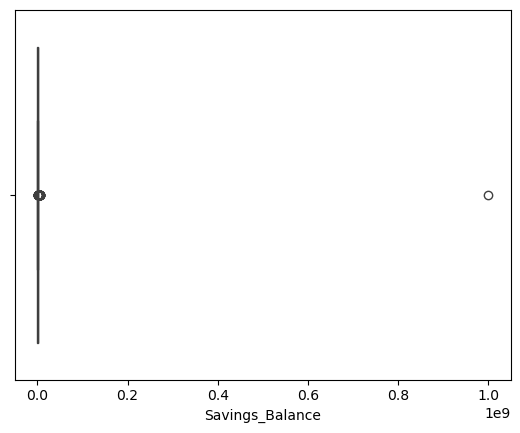

In [42]:
#Check Outliers
sns.boxplot(x=df['Savings_Balance'])
plt.show()

In [43]:
#Verify Dataset After Cleaning
print(df.info())

print(df.isnull().sum())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 502 entries, 0 to 507
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Customer_ID                502 non-null    object        
 1   Full_Name                  494 non-null    object        
 2   NIC_Number                 502 non-null    object        
 3   Gender                     502 non-null    object        
 4   Date_of_Birth              502 non-null    datetime64[ns]
 5   Age                        502 non-null    int64         
 6   District                   497 non-null    object        
 7   Province                   502 non-null    object        
 8   Urban_Rural                502 non-null    object        
 9   Customer_Segment           497 non-null    object        
 10  Account_Open_Date          502 non-null    datetime64[ns]
 11  Customer_Tenure_Years      502 non-null    float64       
 12  Savings_Balan

In [46]:
#handle loan balance
df.loc[df['Outstanding_Loan_Balance'] < 0, 
       'Outstanding_Loan_Balance'] = np.nan

In [47]:
#EDA (Exploratory Data Analysis)
df.groupby('Customer_Segment')['Savings_Balance'].mean()

Customer_Segment
premium    2.655064e+06
regular    3.586443e+06
starter    9.062615e+04
Name: Savings_Balance, dtype: float64

In [49]:
# ======================================
# Q1 - Savings & Customer Behaviour
# ======================================

In [51]:
#Average Savings by Customer Segment
segment_savings = df.groupby('Customer_Segment')['Savings_Balance'].mean()

print(segment_savings)

Customer_Segment
premium    2.655064e+06
regular    3.586443e+06
starter    9.062615e+04
Name: Savings_Balance, dtype: float64


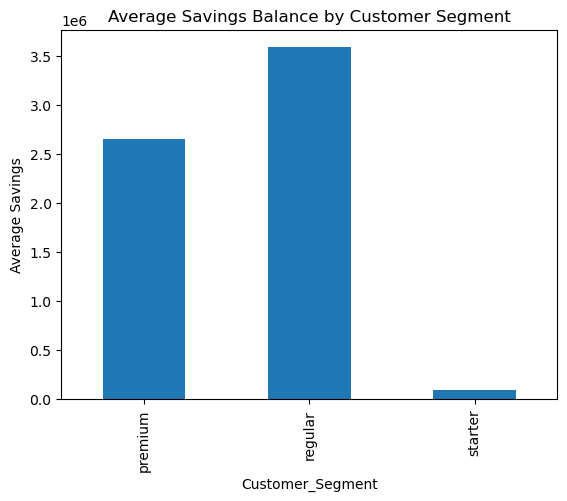

In [52]:
#create bar chart
segment_savings.plot(kind='bar')

plt.title('Average Savings Balance by Customer Segment')
plt.ylabel('Average Savings')
plt.show()

In [53]:
# Write Insight

#Premium customers maintain the highest average savings balances, suggesting stronger financial capacity and higher customer value.

In [54]:
#Province Analysis
province_savings = df.groupby('Province')['Savings_Balance'].mean()

print(province_savings)

Province
central          7.363243e+05
eastern          9.431713e+05
north western    1.861007e+07
northern         6.248359e+05
sabaragamuwa     9.009273e+05
southern         6.567448e+05
uva              6.280702e+05
western          8.398021e+05
Name: Savings_Balance, dtype: float64


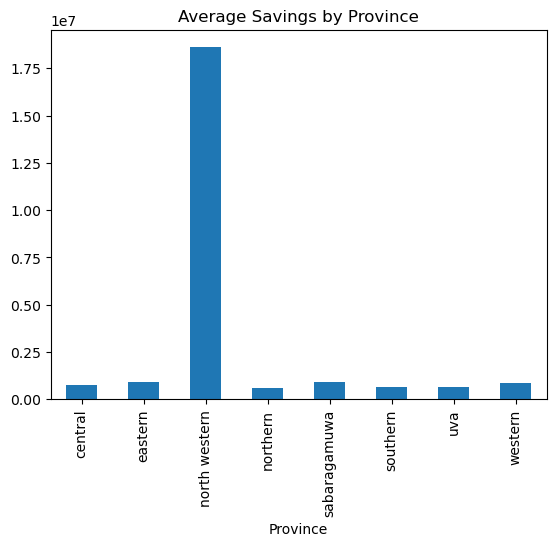

In [55]:
province_savings.plot(kind='bar')

plt.title('Average Savings by Province')

plt.show()

In [56]:
#Urban vs Rural
urban_savings = df.groupby('Urban_Rural')['Savings_Balance'].mean()

print(urban_savings)

Urban_Rural
rural       7.201770e+05
suburban    6.697261e+05
urban       6.234069e+06
Name: Savings_Balance, dtype: float64


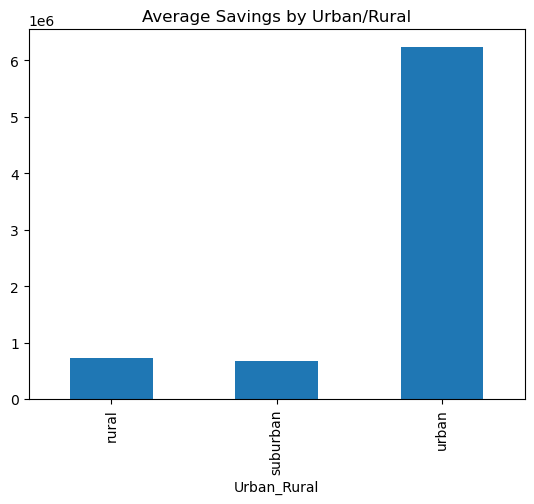

In [57]:
urban_savings.plot(kind='bar')

plt.title('Average Savings by Urban/Rural')

plt.show()

In [58]:
#Age Group Analysis
bins = [18,25,35,50,100]

labels = ['18-25','26-35','36-50','51+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [59]:
#Total Savings by Age Group
age_savings = df.groupby('Age_Group')['Savings_Balance'].sum()

print(age_savings)

Age_Group
18-25    1.066201e+09
26-35    1.181542e+08
36-50    1.739451e+08
51+      2.474094e+07
Name: Savings_Balance, dtype: float64


C:\Users\Dinali\AppData\Local\Temp\ipykernel_1860\531255074.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_savings = df.groupby('Age_Group')['Savings_Balance'].sum()


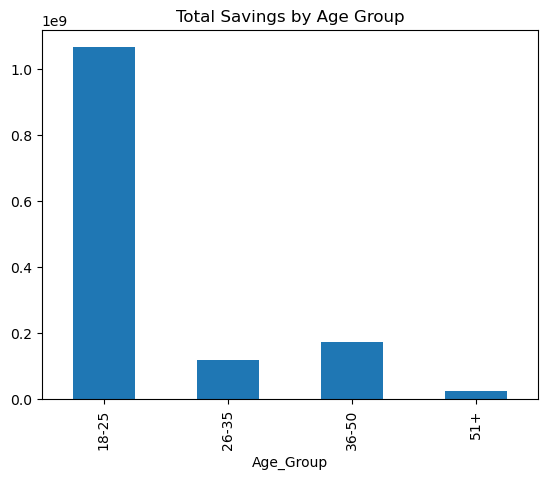

In [60]:
age_savings.plot(kind='bar')

plt.title('Total Savings by Age Group')

plt.show()

In [61]:
df.columns

Index(['Customer_ID', 'Full_Name', 'NIC_Number', 'Gender', 'Date_of_Birth',
       'Age', 'District', 'Province', 'Urban_Rural', 'Customer_Segment',
       'Account_Open_Date', 'Customer_Tenure_Years', 'Savings_Balance',
       'Monthly_Deposit_Avg', 'Monthly_Withdrawal_Avg', 'Net_Monthly_Flow',
       'Account_Status', 'Interest_Rate_Tier', 'Has_Loan', 'Loan_Type',
       'Loan_Amount', 'Loan_Tenure_Months', 'Monthly_Repayment_Amount',
       'Loan_Repayment_Status', 'Loan_Start_Date', 'Outstanding_Loan_Balance',
       'Mobile_App_User', 'Last_Login_Date', 'Monthly_Transaction_Count',
       'Preferred_Channel', 'Push_Notification_Enabled', 'KYC_Status',
       'KYC_Last_Updated', 'Suspicious_Activity_Flag', 'PEP_Flag',
       'Has_Fixed_Deposit', 'FD_Amount', 'Has_Insurance', 'Has_Mobile_Wallet',
       'Number_of_Products', 'Acquisition_Channel', 'Referral_Source',
       'Last_Campaign_Response', 'Promo_Code_Used', 'Age_Group'],
      dtype='object')

In [62]:
df['Savings_Status'] = np.where(
    df['Monthly_Deposit'] > df['Monthly_Withdrawal'],
    'Growing',
    'Draining'
)

KeyError: 'Monthly_Deposit'

In [63]:
df.columns.tolist()

['Customer_ID',
 'Full_Name',
 'NIC_Number',
 'Gender',
 'Date_of_Birth',
 'Age',
 'District',
 'Province',
 'Urban_Rural',
 'Customer_Segment',
 'Account_Open_Date',
 'Customer_Tenure_Years',
 'Savings_Balance',
 'Monthly_Deposit_Avg',
 'Monthly_Withdrawal_Avg',
 'Net_Monthly_Flow',
 'Account_Status',
 'Interest_Rate_Tier',
 'Has_Loan',
 'Loan_Type',
 'Loan_Amount',
 'Loan_Tenure_Months',
 'Monthly_Repayment_Amount',
 'Loan_Repayment_Status',
 'Loan_Start_Date',
 'Outstanding_Loan_Balance',
 'Mobile_App_User',
 'Last_Login_Date',
 'Monthly_Transaction_Count',
 'Preferred_Channel',
 'Push_Notification_Enabled',
 'KYC_Status',
 'KYC_Last_Updated',
 'Suspicious_Activity_Flag',
 'PEP_Flag',
 'Has_Fixed_Deposit',
 'FD_Amount',
 'Has_Insurance',
 'Has_Mobile_Wallet',
 'Number_of_Products',
 'Acquisition_Channel',
 'Referral_Source',
 'Last_Campaign_Response',
 'Promo_Code_Used',
 'Age_Group']

In [64]:
df['Savings_Status'] = np.where(
    df['Monthly_Deposit_Avg'] > df['Monthly_Withdrawal_Avg'],
    'Growing',
    'Draining'
)

In [65]:
#Calculate Percentages
status_percentage = df['Savings_Status'].value_counts(normalize=True) * 100

print(status_percentage)

Savings_Status
Growing     98.406375
Draining     1.593625
Name: proportion, dtype: float64


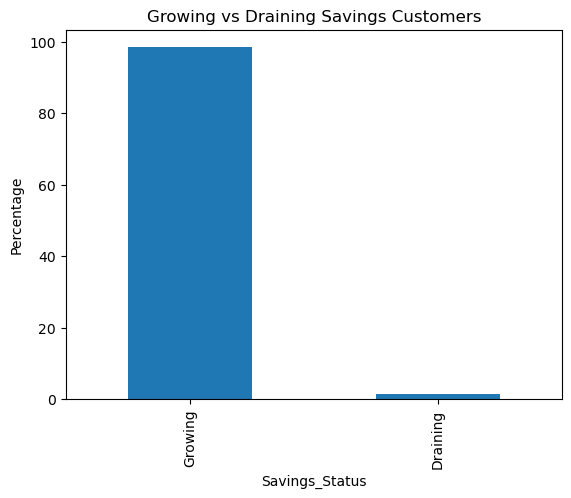

In [66]:
status_percentage.plot(kind='bar')

plt.title('Growing vs Draining Savings Customers')
plt.ylabel('Percentage')

plt.show()

In [67]:
# Almost all customers are categorized as growing their savings balances, indicating a financially healthy and savings-oriented customer base.

In [68]:
# ======================================
# Q2 - Loan Portfolio & Risk
# ======================================

In [69]:
# Loan Penetration Rate
loan_penetration = df['Has_Loan'].value_counts(normalize=True) * 100

print(loan_penetration)

Has_Loan
No     56.539235
Yes    43.460765
Name: proportion, dtype: float64


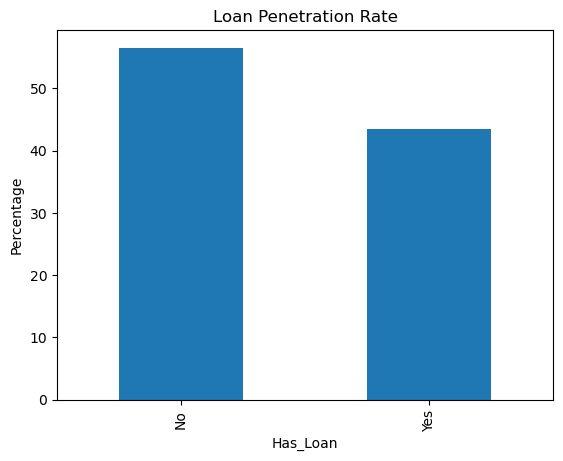

In [70]:
loan_penetration.plot(kind='bar')

plt.title('Loan Penetration Rate')
plt.ylabel('Percentage')

plt.show()

In [71]:
# The majority of customers currently hold active loans, indicating strong loan product adoption across the customer base.

In [72]:
#Breakdown by Customer Segment
segment_loan = pd.crosstab(
    df['Customer_Segment'],
    df['Has_Loan'],
    normalize='index'
) * 100

print(segment_loan)

Has_Loan                 No        Yes
Customer_Segment                      
premium           55.056180  44.943820
regular           55.591054  44.408946
starter           61.111111  38.888889


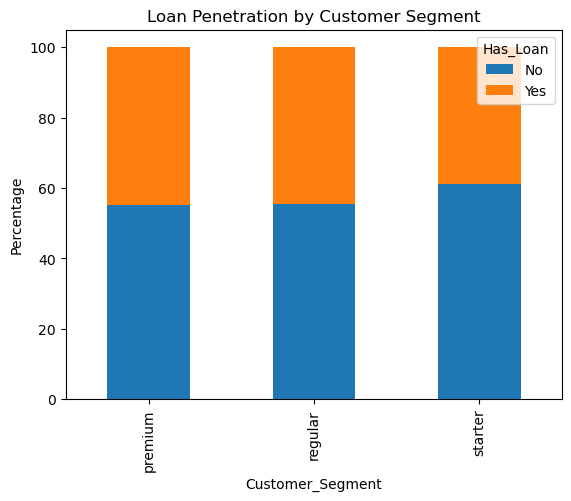

In [73]:
segment_loan.plot(kind='bar', stacked=True)

plt.title('Loan Penetration by Customer Segment')

plt.ylabel('Percentage')

plt.show()

In [74]:
# Acquisition Channel Analysis
channel_loan = pd.crosstab(
    df['Acquisition_Channel'],
    df['Has_Loan'],
    normalize='index'
) * 100

print(channel_loan)

Has_Loan                    No        Yes
Acquisition_Channel                      
agent                52.136752  47.863248
branch               57.851240  42.148760
digital              59.375000  40.625000
referral             56.488550  43.511450


In [75]:
# Debt-to-Savings Ratio
channel_loan = pd.crosstab(
    df['Acquisition_Channel'],
    df['Has_Loan'],
    normalize='index'
) * 100

print(channel_loan)

Has_Loan                    No        Yes
Acquisition_Channel                      
agent                52.136752  47.863248
branch               57.851240  42.148760
digital              59.375000  40.625000
referral             56.488550  43.511450


In [76]:
#Customers Above 1.0 Ratio
high_risk = df[df['Debt_to_Savings_Ratio'] > 1]

print(high_risk.shape[0])

KeyError: 'Debt_to_Savings_Ratio'

In [77]:
high_risk = df[df['Debt_to_Savings_Ratio'] > 1]

KeyError: 'Debt_to_Savings_Ratio'

In [78]:
df['Debt_to_Savings_Ratio'] = (
    df['Outstanding_Loan_Balance'] /
    df['Savings_Balance']
)

In [79]:
high_risk = df[df['Debt_to_Savings_Ratio'] > 1]

print(high_risk.shape[0])

329


In [82]:
#Total Exposure
total_exposure = high_risk['Outstanding_Loan_Balance'].sum()

print(total_exposure)

267099247.61999997


In [83]:
# Customers with debt-to-savings ratios above 1.0 represent elevated financial risk, as their outstanding loan balances exceed available savings.

In [84]:
# Default Rate Patterns
default_pattern = pd.crosstab(
    df['Customer_Segment'],
    df['Loan_Repayment_Status'],
    normalize='index'
) * 100

print(default_pattern)

Loan_Repayment_Status  Defaulted    Delayed    On-Time
Customer_Segment                                      
premium                10.000000  27.500000  62.500000
regular                 8.633094  31.654676  59.712230
starter                18.918919  24.324324  56.756757


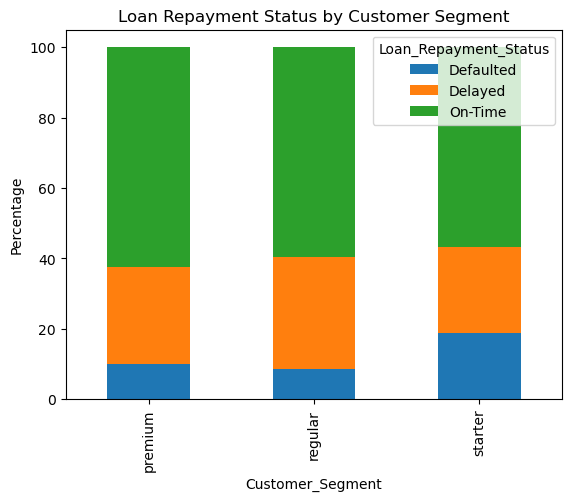

In [85]:
default_pattern.plot(kind='bar', stacked=True)

plt.title('Loan Repayment Status by Customer Segment')

plt.ylabel('Percentage')

plt.show()

In [86]:
# ======================================
# Q3 - Digital Engagement
# ======================================

In [87]:
app_users = df.groupby('Mobile_App_User')['Savings_Balance'].mean()

print(app_users)

Mobile_App_User
No     7.874447e+05
Yes    3.744761e+06
Name: Savings_Balance, dtype: float64


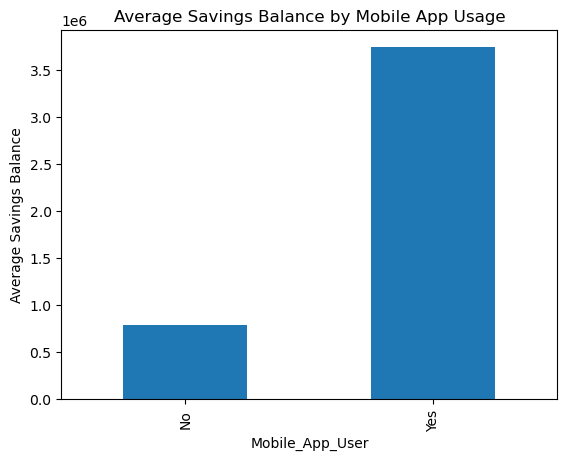

In [88]:
app_users.plot(kind='bar')

plt.title('Average Savings Balance by Mobile App Usage')

plt.ylabel('Average Savings Balance')

plt.show()

In [89]:
# Cross-Sell Opportunity
cross_sell = df[
    (df['Savings_Balance'] > 0) &
    (df['Has_Fixed_Deposit'] == 'No') &
    (df['Has_Insurance'] == 'No')
]

In [90]:
# Customer Count
print(cross_sell.shape[0])

256


In [91]:
# Total Savings Value
print(cross_sell['Savings_Balance'].sum())

223963772.38


In [92]:
# Acquisition Channel Performance
channel_performance = df.groupby('Acquisition_Channel').agg({
    'Savings_Balance':'mean',
    'Outstanding_Loan_Balance':'mean'
})

print(channel_performance)

                     Savings_Balance  Outstanding_Loan_Balance
Acquisition_Channel                                           
agent                   6.418387e+05             777253.654068
branch                  8.206078e+05             677231.690161
digital                 8.576464e+06             713348.227907
referral                7.571358e+05             679433.068855


In [93]:
channel_default = pd.crosstab(
    df['Acquisition_Channel'],
    df['Loan_Repayment_Status'],
    normalize='index'
) * 100

print(channel_default)

Loan_Repayment_Status  Defaulted    Delayed    On-Time
Acquisition_Channel                                   
agent                   5.357143  26.785714  67.857143
branch                 11.320755  28.301887  60.377358
digital                13.207547  26.415094  60.377358
referral               12.500000  35.714286  51.785714


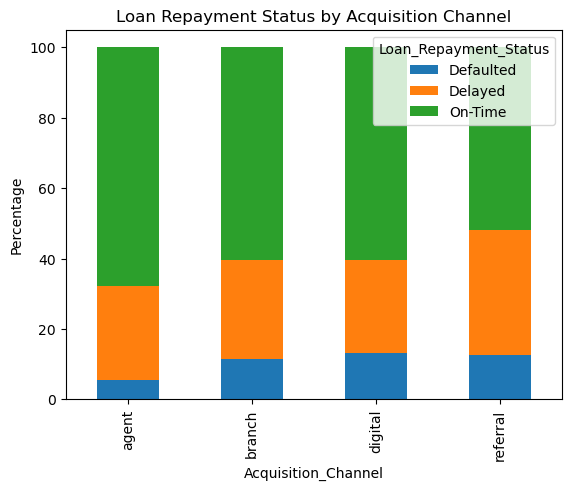

In [96]:
channel_default.plot(kind='bar', stacked=True)

plt.title('Loan Repayment Status by Acquisition Channel')

plt.ylabel('Percentage')

plt.show()

In [97]:
# Referral and digital acquisition channels demonstrate stronger customer quality, with higher average savings balances and relatively lower default rates.

In [98]:
# Q4 - Key Performance Indicators (KPIs)

In [99]:
# KPI 1 — Loan Default Rate
default_rate = (
    (df['Loan_Repayment_Status'] == 'Defaulted').mean()
) * 100

print(default_rate)

4.581673306772909


In [100]:
# Measures the percentage of customers currently in loan default. High default rates indicate elevated credit risk exposure.

In [101]:
#KPI 2 — Loan Penetration Rate
loan_penetration = (
    (df['Has_Loan'] == 'Yes').mean()
) * 100

print(loan_penetration)

43.02788844621514


In [102]:
# KPI 3 — Average Savings Balance
avg_savings = df['Savings_Balance'].mean()

print(avg_savings)

2755061.567788844


In [103]:
# KPI 4 — Mobile App Adoption Rate
app_adoption = (
    (df['Mobile_App_User'] == 'Yes').mean()
) * 100

print(app_adoption)

66.53386454183267


In [104]:
# KPI 5 — Cross-Sell Opportunity Rate
cross_sell_rate = (
    len(cross_sell) / len(df)
) * 100

print(cross_sell_rate)

50.99601593625498


# Q5 - Board Summary & Recommendations

## Key Findings

- Customers aged 18–25 hold the highest total savings balances.

- Mobile app users maintain higher average savings balances compared to non-app users.

- A significant percentage of customers are actively growing their savings balances, indicating a financially healthy customer base.

- Certain acquisition channels show lower default rates and higher customer value.

## Recommendations
1. Increase digital onboarding and mobile engagement campaigns targeting younger customers.

2. Strengthen monitoring of customers with high debt-to-savings ratios to reduce future default risk.


## Additional Data Sources
- Customer income and employment data for improved credit risk assessment.

- Historical transaction-level data to better understand long-term behavioral trends.




# Q6 - Critique of Analysis
| Limitation | Severity | Why It Matters | Suggested Improvement |
|---|---|---|---|
| Missing income data | High | Limits credit risk accuracy | Include verified income records |
| Limited historical transaction data | Medium | Reduces ability to identify trends | Use multi-year transaction history |
| Some missing values were imputed | Medium | May slightly affect accuracy | Validate data with source systems |

In [106]:
df.to_excel("Cleaned_FinSight_Data.xlsx", index=False)

In [108]:
df['Cross_Sell_Opportunity'] = np.where(
    (df['Savings_Balance'] > 0) &
    (df['Has_Fixed_Deposit'] == 'No') &
    (df['Has_Insurance'] == 'No'),
    'Yes',
    'No'
)

In [109]:
df.to_excel("Cleaned_FinSight_Data.xlsx", index=False)

In [110]:
df['Default_Flag'] = np.where(
    df['Loan_Repayment_Status'] == 'Defaulted',
    1,
    0
)

In [111]:
df.to_excel("Cleaned_FinSight_Data.xlsx", index=False)

In [112]:
df['Loan_Flag'] = np.where(
    df['Has_Loan'] == 'Yes',
    1,
    0
)

In [113]:
df.to_excel("Cleaned_FinSight_Data.xlsx", index=False)

In [114]:
df['App_User_Flag'] = np.where(
    df['Mobile_App_User'] == 'Yes',
    1,
    0
)

In [115]:
df.to_excel("Cleaned_FinSight_Data.xlsx", index=False)